In [1]:
import pandas as pd

# 1. Load the movie dataset
# (Make sure the CSV file is in the same folder as your Jupyter Notebook)
df = pd.read_csv("movies_updated.csv")

# 2. Display the first five rows
print("--- First Five Rows ---")
print(df.head())
print("\n" + "="*50 + "\n")

# 3. Display the number of rows and columns
print("--- Dataset Shape (Rows, Columns) ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\n" + "="*50 + "\n")

# 4. Display the column names
print("--- Column Names ---")
print(df.columns.tolist())
print("\n" + "="*50 + "\n")

# 5. Display the data types of each column
print("--- Data Types ---")
print(df.dtypes)

--- First Five Rows ---
                                             name rating      genre  year  \
0                                     The Shining      R      Drama  1980   
1                                 The Blue Lagoon      R  Adventure  1980   
2  Star Wars: Episode V - The Empire Strikes Back     PG     Action  1980   
3                                       Airplane!     PG     Comedy  1980   
4                                      Caddyshack      R     Comedy  1980   

                        released  score    votes         director  \
0  June 13, 1980 (United States)    8.4   927000  Stanley Kubrick   
1   July 2, 1980 (United States)    5.8    65000   Randal Kleiser   
2  June 20, 1980 (United States)    8.7  1200000   Irvin Kershner   
3   July 2, 1980 (United States)    7.7   221000     Jim Abrahams   
4  July 25, 1980 (United States)    7.3   108000     Harold Ramis   

                    writer            star         country    budget  \
0             Stephen King

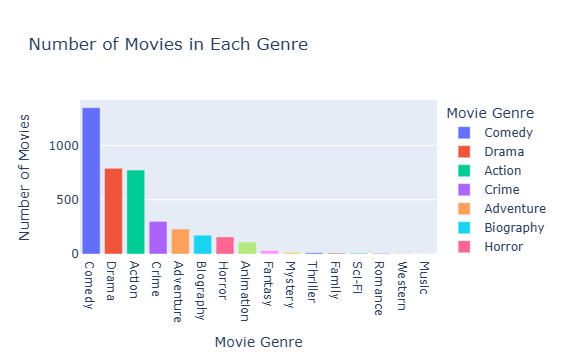

In [16]:
import plotly.express as px

# Count the number of movies in each genre
genre_counts = df['genre'].value_counts().reset_index()
genre_counts.columns = ['genre', 'movie_count']

# Create the bar chart using Plotly Express
fig2 = px.bar(
    genre_counts, 
    x='genre', 
    y='movie_count', 
    color='genre',  # Use different colors for each genre
    title='Number of Movies in Each Genre',
    labels={'genre': 'Movie Genre', 'movie_count': 'Number of Movies'}  # Axis labels
)

# Display the chart
fig2.show()

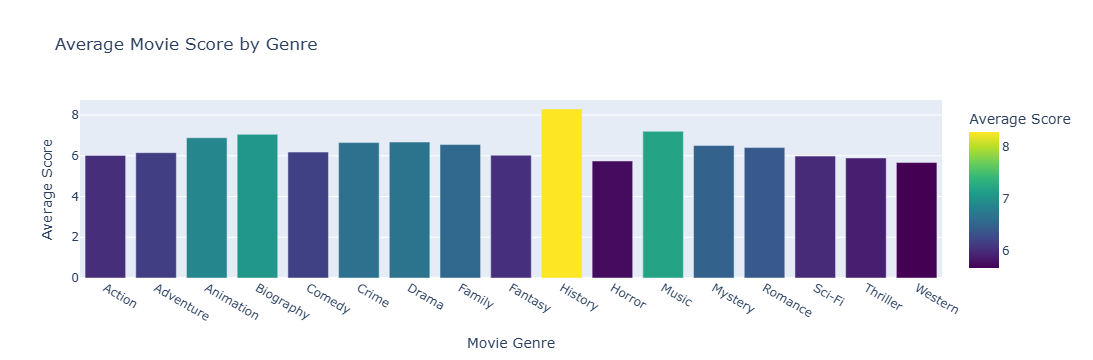

In [3]:
import plotly.express as px

# Calculate the average movie score for each genre
genre_scores = df.groupby('genre')['score'].mean().reset_index()

# Create the bar chart
fig3 = px.bar(
    genre_scores,
    x='genre',
    y='score',
    color='score',  # Color the bars using the continuous scale of average scores
    color_continuous_scale='Viridis',  # A nice built-in color gradient
    title='Average Movie Score by Genre',
    labels={'genre': 'Movie Genre', 'score': 'Average Score'}
)

# Display the chart
fig3.show()

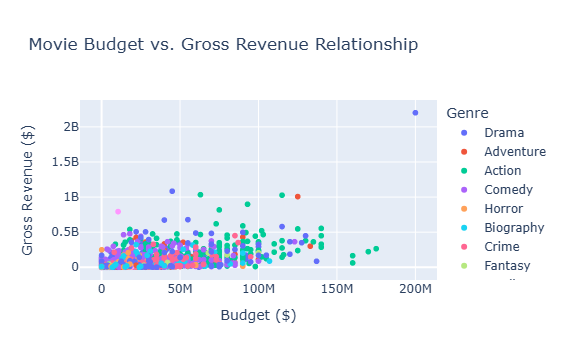

In [18]:
import plotly.express as px

# Create the scatter plot
fig4 = px.scatter(
    df,
    x='budget',
    y='gross',
    color='genre',       # Color the points by genre
    hover_name='name',   # Display the movie name when hovering over a point
    title='Movie Budget vs. Gross Revenue Relationship',
    labels={'budget': 'Budget ($)', 'gross': 'Gross Revenue ($)', 'genre': 'Genre'}
)

# Display the chart
fig4.show()

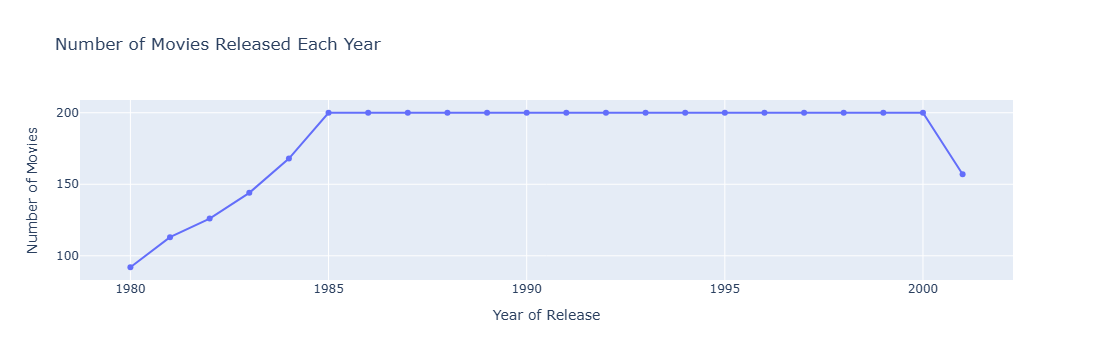

In [5]:
import plotly.express as px

# Count the number of movies released each year
yearly_counts = df['year'].value_counts().reset_index()
yearly_counts.columns = ['year', 'movie_count']

# Sort by year so the line chart reads correctly from left to right
yearly_counts = yearly_counts.sort_values(by='year')

# Create the line chart
fig5 = px.line(
    yearly_counts,
    x='year',
    y='movie_count',
    markers=True,  # Use markers on the data points
    title='Number of Movies Released Each Year',
    labels={'year': 'Year of Release', 'movie_count': 'Number of Movies'}
)

# Display the chart
fig5.show()

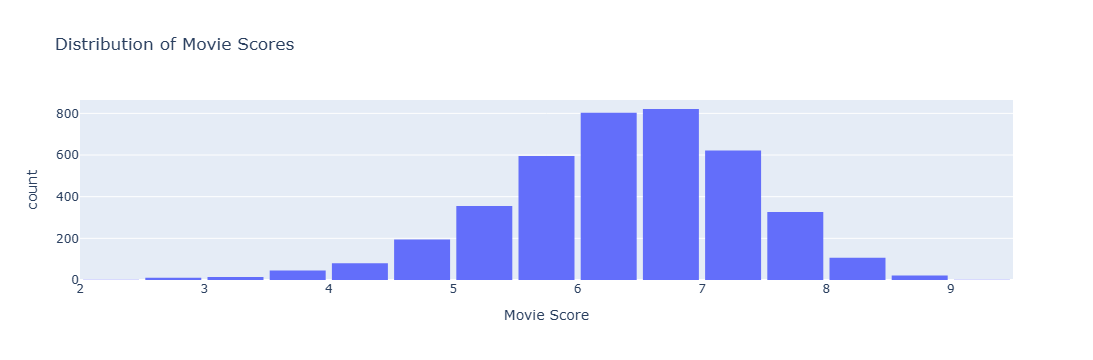

In [6]:
import plotly.express as px

# Create the histogram for movie scores
fig6 = px.histogram(
    df, 
    x='score', 
    nbins=20,  # Explicitly setting an appropriate number of bins
    title='Distribution of Movie Scores',
    labels={'score': 'Movie Score', 'count': 'Number of Movies'}
)

# Improve layout appearance
fig6.update_layout(bargap=0.1)
fig6.show()

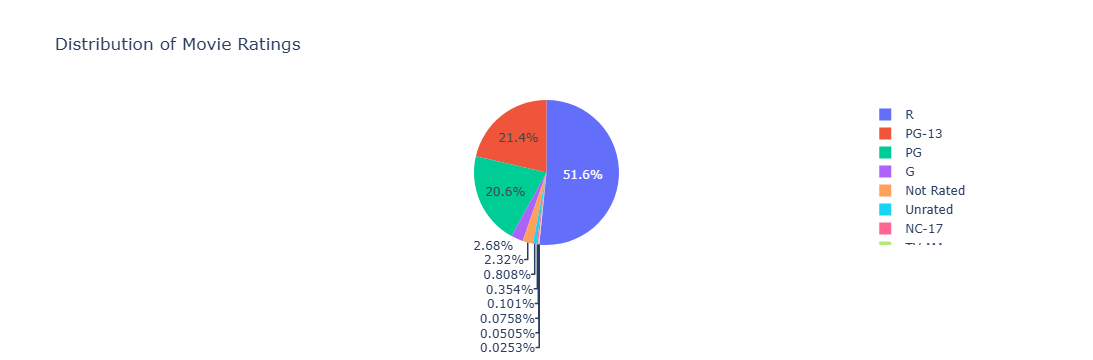

In [8]:
import plotly.express as px

# Count occurrences of each rating (PG, R, PG-13, etc.)
rating_counts = df['rating'].value_counts().reset_index()
rating_counts.columns = ['rating', 'count']

# Create the pie chart
fig7 = px.pie(
    rating_counts, 
    values='count', 
    names='rating', 
    title='Distribution of Movie Ratings'
)
fig7.show()

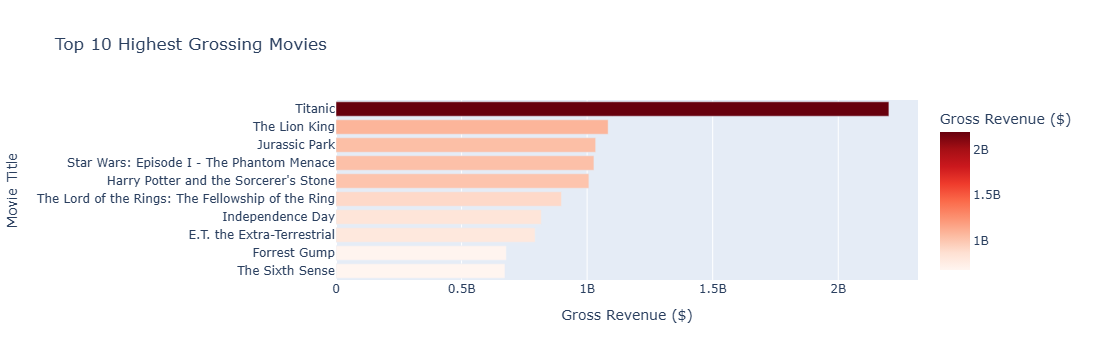

In [9]:
import plotly.express as px

# Filter for top 10 movies sorted by gross revenue
top_10_gross = df.nlargest(10, 'gross')

# Create a horizontal bar chart
fig8 = px.bar(
    top_10_gross, 
    x='gross', 
    y='name', 
    orientation='h',         # Makes the bar chart horizontal
    color='gross',           # Color based on gross revenue
    color_continuous_scale='Reds',
    title='Top 10 Highest Grossing Movies',
    labels={'gross': 'Gross Revenue ($)', 'name': 'Movie Title'}
)

# Sort the y-axis so the highest grossing movie appears at the very top
fig8.update_layout(yaxis={'categoryorder':'total ascending'})
fig8.show()

In [12]:
import pandas as pd
import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import plotly.express as px

# ==========================================
# 1. DATA LOADING AND CLEANING
# ==========================================
# Load dataset
df = pd.read_csv("movies_updated.csv")

# Ensure required columns are present and data types are correct
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df['score'] = pd.to_numeric(df['score'], errors='coerce')
df['budget'] = pd.to_numeric(df['budget'], errors='coerce')
df['gross'] = pd.to_numeric(df['gross'], errors='coerce')

# Drop missing values in critical sorting/filtering columns to avoid slider crashes
df = df.dropna(subset=['year', 'genre', 'rating'])

# Get min and max years for our Range Slider
min_year = int(df['year'].min())
max_year = int(df['year'].max())

# ==========================================
# 2. DASH APPLICATION SETUP & STYLING
# ==========================================
app = dash.Dash(__name__)

# CSS Stylesheet Dictionary for enhanced visual layout (Exercise 13 requirements)
COLORS = {
    'background': '#f4f6f9',
    'card-bg': '#ffffff',
    'text': '#2c3e50',
    'accent': '#3498db'
}

app.layout = html.Div(style={'backgroundColor': COLORS['background'], 'padding': '20px', 'fontFamily': 'Arial, sans-serif'}, children=[
    
    # Dashboard Header Title Section
    html.Div([
        html.H1("Movie Analytics Dashboard", style={'textAlign': 'center', 'color': COLORS['text'], 'marginBottom': '10px'}),
        html.P("Interactive insights built on the Movie Dataset", style={'textAlign': 'center', 'color': '#7f8c8d', 'fontSize': '16px'}),
        html.Hr(style={'borderColor': COLORS['accent'], 'width': '80%', 'marginBottom': '30px'})
    ]),
    
    # FILTERS PANEL SECTION (Exercises 9, 10, 12, & Final Challenge)
    html.Div(style={
        'backgroundColor': COLORS['card-bg'], 'padding': '25px', 'borderRadius': '8px',
        'boxShadow': '0 4px 6px rgba(0,0,0,0.1)', 'marginBottom': '25px'
    }, children=[
        html.H3("Interactive Controls & Filters", style={'marginTop': '0', 'color': COLORS['text']}),
        
        # Grid System for Dropdowns
        html.Div(style={'display': 'flex', 'flexWrap': 'wrap', 'gap': '20px'}, children=[
            
            # Genre Filter (Exercise 9)
            html.Div(style={'flex': '1', 'minWidth': '200px'}, children=[
                html.Label("Select Genre:", style={'fontWeight': 'bold', 'color': COLORS['text']}),
                dcc.Dropdown(
                    id='genre-dropdown',
                    options=[{'label': 'All Genres', 'value': 'All'}] + [{'label': g, 'value': g} for g in sorted(df['genre'].unique())],
                    value='All',
                    clearable=False
                )
            ]),
            
            # Rating Filter (Exercise 10)
            html.Div(style={'flex': '1', 'minWidth': '200px'}, children=[
                html.Label("Select Content Rating:", style={'fontWeight': 'bold', 'color': COLORS['text']}),
                dcc.Dropdown(
                    id='rating-dropdown',
                    options=[{'label': 'All Ratings', 'value': 'All'}] + [{'label': r, 'value': r} for r in sorted(df['rating'].unique())],
                    value='All',
                    clearable=False
                )
            ]),
            
            # Country Filter (Final Challenge Requirement)
            html.Div(style={'flex': '1', 'minWidth': '200px'}, children=[
                html.Label("Select Country:", style={'fontWeight': 'bold', 'color': COLORS['text']}),
                dcc.Dropdown(
                    id='country-dropdown',
                    options=[{'label': 'All Countries', 'value': 'All'}] + [{'label': str(c), 'value': str(c)} for c in sorted(df['country'].dropna().unique())],
                    value='All',
                    clearable=False
                )
            ]),
        ]),
        
        # Year Range Slider (Exercise 12)
        html.Div(style={'marginTop': '25px'}, children=[
            html.Label("Select Year Range:", style={'fontWeight': 'bold', 'color': COLORS['text']}),
            html.Div(style={'padding': '10px 0'}, children=[
                dcc.RangeSlider(
                    id='year-slider',
                    min=min_year,
                    max=max_year,
                    step=1,
                    value=[min_year, max_year],
                    marks={year: str(year) for year in range(min_year, max_year + 1, 5) if year <= max_year},
                    tooltip={"placement": "bottom", "always_visible": True}
                )
            ])
        ])
    ]),
    
    # VISUALIZATION GRID LAYOUT SECTION (Exercise 11, 13 & Final Challenge Metrics)
    # Row 1 (Two Columns)
    html.Div(style={'display': 'flex', 'flexWrap': 'wrap', 'gap': '20px', 'marginBottom': '20px'}, children=[
        html.Div(style={'flex': '1', 'minWidth': '450px', 'backgroundColor': COLORS['card-bg'], 'padding': '15px', 'borderRadius': '8px', 'boxShadow': '0 4px 6px rgba(0,0,0,0.05)'}, children=[
            dcc.Graph(id='score-by-rating-bar') # Graph 1 (Exercise 9 & 13)
        ]),
        html.Div(style={'flex': '1', 'minWidth': '450px', 'backgroundColor': COLORS['card-bg'], 'padding': '15px', 'borderRadius': '8px', 'boxShadow': '0 4px 6px rgba(0,0,0,0.05)'}, children=[
            dcc.Graph(id='rating-distribution-pie') # Graph 2 (Exercise 11 & 13)
        ])
    ]),
    
    # Row 2 (Two Columns)
    html.Div(style={'display': 'flex', 'flexWrap': 'wrap', 'gap': '20px', 'marginBottom': '20px'}, children=[
        html.Div(style={'flex': '1', 'minWidth': '450px', 'backgroundColor': COLORS['card-bg'], 'padding': '15px', 'borderRadius': '8px', 'boxShadow': '0 4px 6px rgba(0,0,0,0.05)'}, children=[
            dcc.Graph(id='budget-vs-gross-scatter') # Graph 3 (Exercise 11)
        ]),
        html.Div(style={'flex': '1', 'minWidth': '450px', 'backgroundColor': COLORS['card-bg'], 'padding': '15px', 'borderRadius': '8px', 'boxShadow': '0 4px 6px rgba(0,0,0,0.05)'}, children=[
            dcc.Graph(id='movies-per-year-line') # Graph 4 (Exercise 11)
        ])
    ]),
    
    # Row 3 (Two Columns)
    html.Div(style={'display': 'flex', 'flexWrap': 'wrap', 'gap': '20px'}, children=[
        html.Div(style={'flex': '1', 'minWidth': '450px', 'backgroundColor': COLORS['card-bg'], 'padding': '15px', 'borderRadius': '8px', 'boxShadow': '0 4px 6px rgba(0,0,0,0.05)'}, children=[
            dcc.Graph(id='top-grossing-horizontal-bar') # Graph 5 (Exercise 13)
        ]),
        html.Div(style={'flex': '1', 'minWidth': '450px', 'backgroundColor': COLORS['card-bg'], 'padding': '15px', 'borderRadius': '8px', 'boxShadow': '0 4px 6px rgba(0,0,0,0.05)'}, children=[
            dcc.Graph(id='movies-by-genre-bar') # Graph 6 (Final Challenge Requirement)
        ])
    ])
])


# ==========================================
# 3. INTERACTIVE CALLBACK LOGIC
# ==========================================
@app.callback(
    [Output('score-by-rating-bar', 'figure'),
     Output('rating-distribution-pie', 'figure'),
     Output('budget-vs-gross-scatter', 'figure'),
     Output('movies-per-year-line', 'figure'),
     Output('top-grossing-horizontal-bar', 'figure'),
     Output('movies-by-genre-bar', 'figure')],
    [Input('genre-dropdown', 'value'),
     Input('rating-dropdown', 'value'),
     Input('country-dropdown', 'value'),
     Input('year-slider', 'value')]
)
def update_dashboard(selected_genre, selected_rating, selected_country, selected_years):
    # Step 3a: Filter base dataframe dynamically based on active dashboard selections
    filtered_df = df[
        (df['year'] >= selected_years[0]) & 
        (df['year'] <= selected_years[1])
    ]
    
    if selected_genre != 'All':
        filtered_df = filtered_df[filtered_df['genre'] == selected_genre]
        
    if selected_rating != 'All':
        filtered_df = filtered_df[filtered_df['rating'] == selected_rating]
        
    if selected_country != 'All':
        filtered_df = filtered_df[filtered_df['country'] == selected_country]
        
    # Standard placeholder configuration for when data filters result in an empty set
    empty_layout = {"layout": {"annotations": [{"text": "No data matches the selected filters", "xref": "paper", "yref": "paper", "showarrow": False, "font": {"size": 16}}]}}

    if filtered_df.empty:
        return empty_layout, empty_layout, empty_layout, empty_layout, empty_layout, empty_layout

    # ----------------------------------------------------
    # GRAPH 1: Average Movie Score by Rating (Exercise 9 Requirement)
    # ----------------------------------------------------
    avg_score_rating = filtered_df.groupby('rating')['score'].mean().reset_index()
    fig1 = px.bar(
        avg_score_rating, x='rating', y='score', color='score',
        color_continuous_scale='Blues', title='Average Movie Score by Content Rating',
        labels={'rating': 'Content Rating', 'score': 'Average Score'}
    )
    
    # ----------------------------------------------------
    # GRAPH 2: Movie Rating Distribution (Exercise 11 / Pie Chart)
    # ----------------------------------------------------
    rating_counts = filtered_df['rating'].value_counts().reset_index()
    rating_counts.columns = ['rating', 'count']
    fig2 = px.pie(
        rating_counts, values='count', names='rating', 
        title='Movie Rating Breakdown Across Filtered Range',
        hole=0.3 # Visual upgrade: Donut Chart style
    )
    
    # ----------------------------------------------------
    # GRAPH 3: Budget vs Gross Revenue (Exercise 11 / Scatter Plot)
    # ----------------------------------------------------
    fig3 = px.scatter(
        filtered_df, x='budget', y='gross', color='genre', hover_name='name',
        title='Financial Matrix: Budget vs Gross Revenue',
        labels={'budget': 'Budget ($)', 'gross': 'Gross Profits ($)'}
    )
    
    # ----------------------------------------------------
    # GRAPH 4: Movies Released Per Year (Exercise 11 / Line Chart)
    # ----------------------------------------------------
    yearly_distribution = filtered_df['year'].value_counts().reset_index().sort_values('year')
    yearly_distribution.columns = ['year', 'count']
    fig4 = px.line(
        yearly_distribution, x='year', y='count', markers=True,
        title='Historical Production: Movies Distributed Annually',
        labels={'year': 'Year', 'count': 'Total Movies Written'}
    )
    fig4.update_traces(line_color='#2ecc71')

    # ----------------------------------------------------
    # GRAPH 5: Top 10 Highest Grossing Movies (Exercise 13 / Horizontal)
    # ----------------------------------------------------
    top_10 = filtered_df.nlargest(10, 'gross')
    fig5 = px.bar(
        top_10, x='gross', y='name', orientation='h', color='gross',
        color_continuous_scale='Plasma', title='Top 10 Highest Grossing Movies Matrix',
        labels={'gross': 'Box Office Revenue ($)', 'name': 'Movie Title'}
    )
    fig5.update_layout(yaxis={'categoryorder':'total ascending'})

    # ----------------------------------------------------
    # GRAPH 6: Total Movies by Genre (Final Challenge Requirement)
    # ----------------------------------------------------
    genre_metrics = filtered_df['genre'].value_counts().reset_index()
    genre_metrics.columns = ['genre', 'count']
    fig6 = px.bar(
        genre_metrics, x='genre', y='count', color='genre',
        title='Volume Output Distributed by Movie Genre',
        labels={'genre': 'Genre Classification', 'count': 'Volume Metrics'}
    )
    
    # Unified layout cleanups across all interactive subcomponents
    for fig in [fig1, fig2, fig3, fig4, fig5, fig6]:
        fig.update_layout(margin=dict(l=20, r=20, t=40, b=20))
        
    return fig1, fig2, fig3, fig4, fig5, fig6

# ==========================================
# 4. RUN SERVER CONTAINER
# ==========================================
if __name__ == '__main__':
    app.run(debug=True)